In [2]:
import dg_geometry as DG503
import sympy as sp
import numpy as np

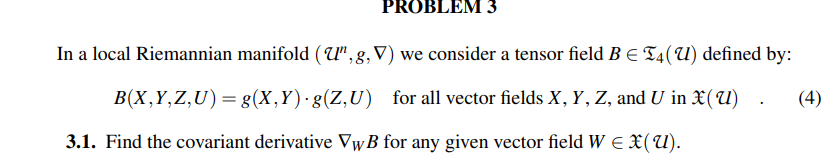

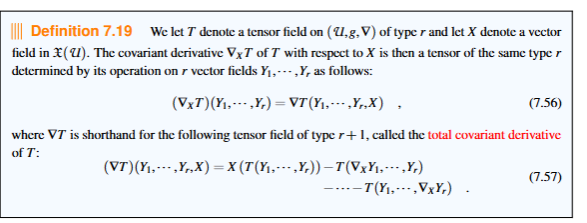

We use 7.19

$ (\nabla_W B)(X, Y, Z, U) = W(B(X, Y, Z, U)) - B(\nabla_W X, Y, Z, U) $ 

$ B(X, \nabla_W Y, Z, U) - B(X, Y, \nabla_W Z, U) - B(X, Y, Z, \nabla_W U) $

We can then input them into the metrics starting with the first term

$(\nabla_W B)(X, Y, Z, U) = W(g(X,Y) \cdot g(Z,U)) =$ 

$W(g(X,Y)) \cdot g(Z,U) + g(X,Y) \cdot W(g(Z,U)) =$ 

$g(Z,U) \cdot (g(\nabla_W X,Y) + g(X,\nabla_W Y))  + g(X,Y) \cdot (g(\nabla_W Z,U) + g(Z,\nabla_W U) )$ 

And the rest of the terms become

$B(\nabla_W X, Y, Z, U) = g(\nabla_W X, Y)g(Z, U)$

$B(X, \nabla_W Y, Z, U) = g(X, \nabla_W Y)g(Z, U)$

$B(X, Y, \nabla_W Z, U) = g(X, Y)g(\nabla_W Z, U)$

$B(X, Y, Z, \nabla_W U) = g(X, Y)g(Z, \nabla_W U)$

We can now see that they all cancel out and become

$\nabla_W B = 0$

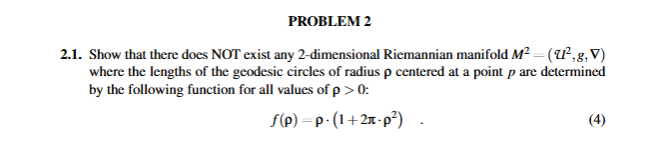

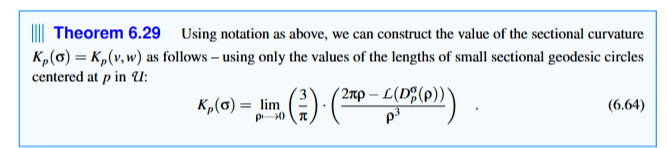

We have 6.29

$K_p = \lim_{\rho \to 0} \left( \frac{3}{\pi} \right) \cdot \left( \frac{2\pi\rho - \mathcal{L}(\rho)}{\rho^3} \right)$

We can input 

$\mathcal{L}(\rho) = f(\rho) = \rho + 2\pi\rho^3$

we can substitute it

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \frac{2\pi\rho - (\rho + 2\pi\rho^3)}{\rho^3}$

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \frac{(2\pi - 1)\rho - 2\pi\rho^3}{\rho^3}$

$K_p = \frac{3}{\pi} \lim_{\rho \to 0} \left[ \frac{2\pi - 1}{\rho^2} - 2\pi \right]$

This can easily be seen to go towards infinity and curvature cant be infinite and therefore there is no manifold with geodesic circles with tadius derternined by the function given



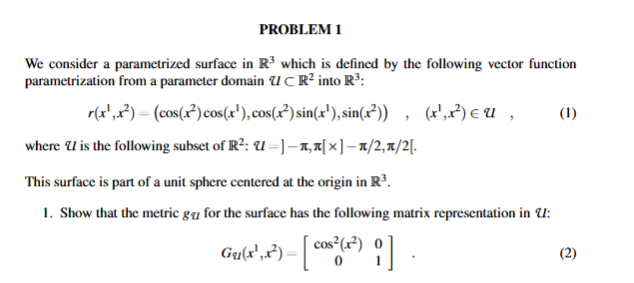

In [3]:
# Coordinates and Parametrization from image_0c5721.png
x1, x2 = sp.symbols('x1 x2', real=True)
r = sp.Matrix([sp.cos(x2)*sp.cos(x1), sp.cos(x2)*sp.sin(x1), sp.sin(x2)])
jac_r = r.jacobian([x1, x2])

display(jac_r)

G_u = sp.simplify(jac_r.T * jac_r)
display(G_u)

Matrix([
[-sin(x1)*cos(x2), -sin(x2)*cos(x1)],
[ cos(x1)*cos(x2), -sin(x1)*sin(x2)],
[               0,          cos(x2)]])

Matrix([
[cos(x2)**2, 0],
[         0, 1]])

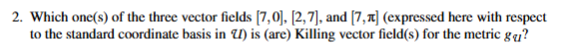

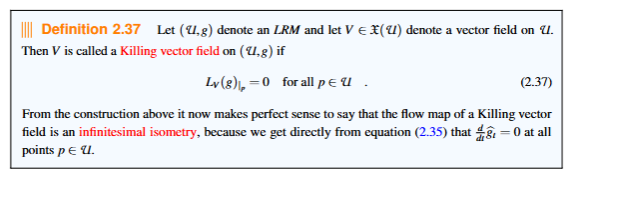

In [4]:
coords = [x1, x2]

V1 = sp.Matrix([[7], [0]])
V2 = sp.Matrix([[2], [7]])
V3 = sp.Matrix([[7], [sp.pi]])

Lv_g1 = DG503.calculate_lie_derivative_metric(G_u, V1,coords)
Lv_g2 = DG503.calculate_lie_derivative_metric(G_u, V2,coords)
Lv_g3 = DG503.calculate_lie_derivative_metric(G_u, V3,coords)

display(Lv_g1)
display(Lv_g2)
display(Lv_g3)

Matrix([
[0, 0],
[0, 0]])

Matrix([
[-7*sin(2*x2), 0],
[           0, 0]])

Matrix([
[-pi*sin(2*x2), 0],
[            0, 0]])

The vector field [7,0] is a killing vectorfield

In [31]:
theta, y1, y2, y3 = sp.symbols('theta y1 y2 y3')
H_v = 1/y3**2 * sp.eye(3)
phi = sp.Matrix([x1,x2*sp.cos(theta),1+x2*sp.sin(theta)])
phi_x1 = phi.diff(x1)
phi_x2 = phi.diff(x2)
phi_mark = sp.Matrix([[phi_x1.T],[phi_x2.T]]).T

H_v_sub = H_v.subs(y3, phi[2])

G_u = sp.simplify(phi_mark.T*H_v.subs(y3, phi[2])*phi_mark) 

display(G_u)

Matrix([
[(x2*sin(theta) + 1)**(-2),                         0],
[                        0, (x2*sin(theta) + 1)**(-2)]])

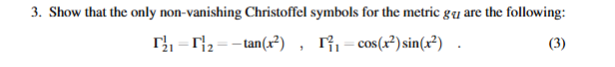

In [6]:
chris = DG503.calculate_christoffel_symbols(G_u, coords)
display(chris)

{(0, 0, 0): 0,
 (0, 0, 1): sin(2*x2)/2,
 (0, 1, 0): -tan(x2),
 (0, 1, 1): 0,
 (1, 0, 0): -tan(x2),
 (1, 0, 1): 0,
 (1, 1, 0): 0,
 (1, 1, 1): 0}

Here 0 is 1 and 1 is 2. it is zero indexed according to python

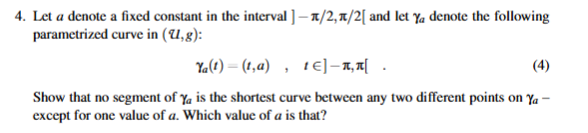

In [7]:
a, t  = sp.symbols('a t', real=True)

gamma = sp.Matrix([t, a])

gamma_dot = gamma.diff(t)

G_gamma = G_u.subs({x1: gamma[0], x2: gamma[1]})

# finding the g length of the curve gamm

acceleration = DG503.calculate_curve_acceleration(G_u, gamma, t, coords)
display(acceleration)

curvature = DG503.calculate_g_norm(G_gamma, acceleration)
display(curvature)

a = sp.solve(curvature, a)
display(a)

Matrix([
[         0],
[sin(2*a)/2]])

Abs(sin(2*a))/2

[0, pi/2]

It has to be geodesic if the curvature and acceleration is 0 so if its is geodesic. It is only 0 if a = 0

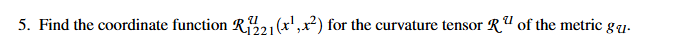

In [8]:
R_tensor = DG503.curvature_tensor(G_u, coords)
display(R_tensor[0,1,1,0])

cos(x2)**2

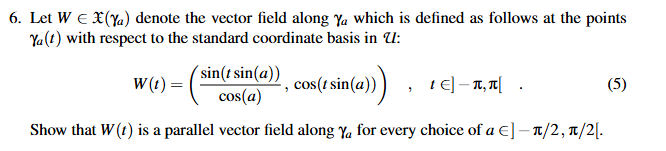

In [9]:
a = sp.symbols('a', real=True)

W = sp.Matrix([sp.sin(t*sp.sin(a))/sp.cos(a), sp.cos(t*sp.sin(a))])
display(W)

cov_along = sp.simplify(DG503.calculate_covariant_derivative_along_curve(G_u, gamma, W, t, coords))
display(cov_along)


Matrix([
[sin(t*sin(a))/cos(a)],
[       cos(t*sin(a))]])

Matrix([
[0],
[0]])

The curves are parrallel

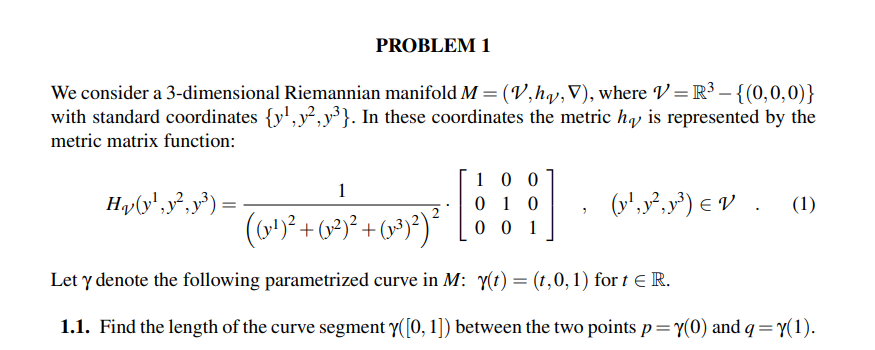

In [10]:
y1, y2, y3, t = sp.symbols('y1 y2 y3 t', real=True)
coords = [y1, y2, y3]

norm_sq = y1**2 + y2**2 + y3**2
h_v_scalar = 1 / (norm_sq**2)
h_v = h_v_scalar * sp.eye(3)
display(h_v)

gamma = sp.Matrix([t, 0, 1])
display(gamma)

gamma_dot = gamma.diff(t)
display(gamma_dot)


Matrix([
[(y1**2 + y2**2 + y3**2)**(-2),                             0,                             0],
[                            0, (y1**2 + y2**2 + y3**2)**(-2),                             0],
[                            0,                             0, (y1**2 + y2**2 + y3**2)**(-2)]])

Matrix([
[t],
[0],
[1]])

Matrix([
[1],
[0],
[0]])

In [11]:

h_at_gamma = h_v.subs({y1: gamma[0], y2: gamma[1], y3: gamma[2]})

speed = DG503.calculate_g_norm(h_at_gamma, gamma_dot)

length = sp.integrate(speed, (t, 0, 1))

print("Metric along curve (H_gamma):")
display(speed)
print("\nTotal length of curve segment gamma([0, 1]):")
display(length)

Metric along curve (H_gamma):


1/(t**2 + 1)


Total length of curve segment gamma([0, 1]):


pi/4

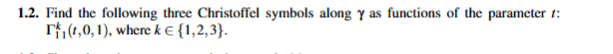

In [12]:
chris = DG503.calculate_christoffel_symbols(h_v, coords)

display(chris[0,0,0].subs({y1: gamma[0], y2: gamma[1], y3: gamma[2]}))
display(chris[1,0,0].subs({y1: gamma[0], y2: gamma[1], y3: gamma[2]}))
display(chris[2,0,0].subs({y1: gamma[0], y2: gamma[1], y3: gamma[2]}))

-2*t/(t**2 + 1)

0

-2/(t**2 + 1)

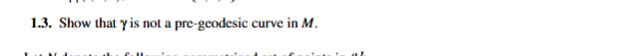

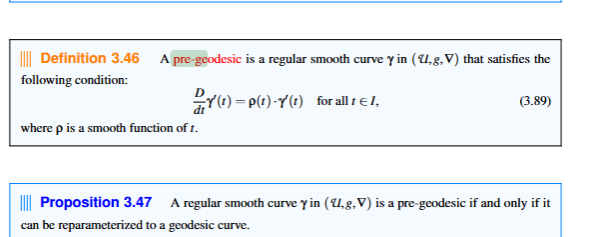

In [13]:
acceleration = DG503.calculate_curve_acceleration(h_v, gamma, t, coords)
display(acceleration)

Matrix([
[-2*t/(t**2 + 1)],
[              0],
[   2/(t**2 + 1)]])

In [14]:
f = sp.Function('f')(t)

eq = sp.Eq(acceleration, f * gamma_dot)
display(acceleration)
display(f * gamma_dot)
display(sp.simplify(eq))

Matrix([
[-2*t/(t**2 + 1)],
[              0],
[   2/(t**2 + 1)]])

Matrix([
[f(t)],
[   0],
[   0]])

False

We can see that no function f(t) can satisfy the criteria for a pregeodesic

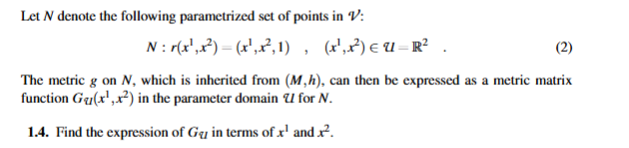

In [15]:
# Coordinates and Parametrization from image_0c5721.png
x1, x2 = sp.symbols('x1 x2', real=True)
r = sp.Matrix([x1, x2, 1])
jac_r = r.jacobian([x1, x2])

display(jac_r)

h_v_at_r = h_v.subs({y1: r[0], y2: r[1], y3: r[2]})
display(h_v_at_r)

G_u = sp.simplify(jac_r.T * h_v_at_r * jac_r)
display(G_u)

Matrix([
[1, 0],
[0, 1],
[0, 0]])

Matrix([
[(x1**2 + x2**2 + 1)**(-2),                         0,                         0],
[                        0, (x1**2 + x2**2 + 1)**(-2),                         0],
[                        0,                         0, (x1**2 + x2**2 + 1)**(-2)]])

Matrix([
[(x1**2 + x2**2 + 1)**(-2),                         0],
[                        0, (x1**2 + x2**2 + 1)**(-2)]])

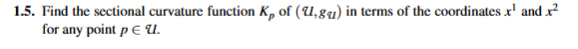

In [16]:
coords = [x1, x2]
pt = sp.Matrix([x1, x2])
x_vec = sp.Matrix([1, 0])
y_vec = sp.Matrix([0, 1])

K_p = DG503.sectional_curvature(G_u, pt, x_vec, y_vec, coords)
display(K_p)


4

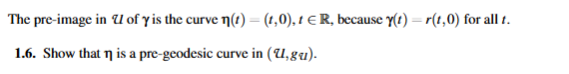

In [17]:
t = sp.symbols('t', real=True)
mu = sp.Matrix([t, 0])
mu_dot = mu.diff(t)

acceleration = DG503.calculate_curve_acceleration(G_u, mu, t, coords)
display(acceleration)
display(mu_dot)
f = sp.Function('f')(t)

eq = sp.Eq(acceleration, f * mu_dot)
display(eq)

Matrix([
[-2*t/(t**2 + 1)],
[              0]])

Matrix([
[1],
[0]])

Eq(Matrix([
[-2*t/(t**2 + 1)],
[              0]]), Matrix([
[f(t)],
[   0]]))

So we can now see a smooth function can satisfy the conditions for a pregeodesic

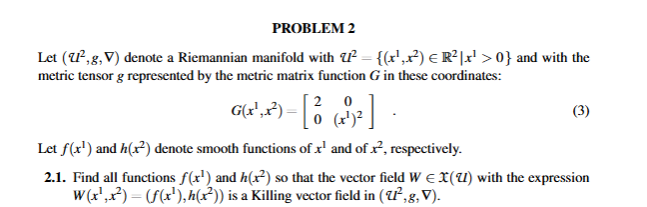

In [18]:
x1, x2, t = sp.symbols('x1 x2 t', real=True)

G = sp.Matrix([[2, 0], [0, x1**2]])
display(G)

f = sp.Function('f')(x1)
h = sp.Function('h')(x2)

W = sp.Matrix([f,h])
display(W)

coords = [x1, x2]

Lv_g = DG503.calculate_lie_derivative_metric(G, W,coords)
display(Lv_g)

eq1 = sp.Eq(Lv_g[0,0], 0)
eq2 = sp.Eq(Lv_g[1,1], 0)

sol1 = sp.dsolve(eq1, f)
sol2 = sp.dsolve(eq2.subs(f, sol1.rhs), h)
display(sol1)
display(sol2)

Matrix([
[2,     0],
[0, x1**2]])

Matrix([
[f(x1)],
[h(x2)]])

Matrix([
[4*Derivative(f(x1), x1),                                       0],
[                      0, 2*x1*(x1*Derivative(h(x2), x2) + f(x1))]])

Eq(f(x1), C1)

Eq(h(x2), -C1*x2/x1 + C2)

Here it can be quite easily seen that the only solution is:

$C_1=0$

This is beacause a function $h(x_2)$ cant be dependend on $x_1$ so we can find $h(x_2)$

$h(x_2) = c$

$h(x_2)$ can then be all real numbers

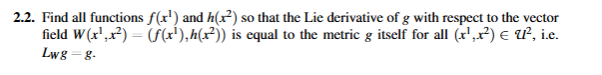

In [19]:
x1, x2, t = sp.symbols('x1 x2 t', real=True)

G = sp.Matrix([[2, 0], [0, x1**2]])
display(G)

f = sp.Function('f')(x1)
h = sp.Function('h')(x2)

W = sp.Matrix([f,h])
display(W)

coords = [x1, x2]

Lv_g = DG503.calculate_lie_derivative_metric(G, W,coords)
display(Lv_g)

eq1 = sp.Eq(Lv_g[0,0], G[0,0])
eq2 = sp.Eq(Lv_g[1,1], G[1,1])

sol1 = sp.dsolve(eq1, f)
sol2 = sp.dsolve(eq2.subs(f, sol1.rhs), h)
display(sol1)
display(sol2)

Matrix([
[2,     0],
[0, x1**2]])

Matrix([
[f(x1)],
[h(x2)]])

Matrix([
[4*Derivative(f(x1), x1),                                       0],
[                      0, 2*x1*(x1*Derivative(h(x2), x2) + f(x1))]])

Eq(f(x1), C1 + x1/2)

Eq(h(x2), -C1*x2/x1 + C2)

Here it can be quite easily seen that the only solution is:

$C_1=0$

This is beacause a function $h(x_2)$ cant be dependend on $x_1$ so we can find $h(x_2)$

$h(x_2) = c$

$h(x_2)$ can then be all real numbers and we can find $f(x_1)$ to be 

$f(x_1) = \frac{x_1}{2}$

In [20]:
# check
C = sp.symbols('C', real=True)
eq = sp.Eq(G, Lv_g.subs({f: x1/2, h: C}))
display(eq)

Eq(Matrix([
[2,     0],
[0, x1**2]]), Matrix([
[4*Derivative(x1/2, x1),                                  0],
[                     0, 2*x1*(x1*Derivative(C, x2) + x1/2)]]))

Cant get it to evaluate but if the derivation is made it is correct